
# 12 — Data Imputation and Encoding

**Scope:** The missing and incorrect values are handled, categorical features are encoded.


Since we decided to predict missing and incorrect values, we have to split the training data into training and validation sets before applying imputation and encoding.

# Table of Contents

1. [Setup & Imports](#sec-setup)
2. [Load Data & Initial Audit](#sec-load)
3. [Imputation Strategies](#sec-imputation-strategies)
    3.1 [Categorical Imputation](#sec-cat-imp)
    3.2 [Numerical Imputation](#sec-num-imp)
4. [Imputation Pipeline](#sec-imp-pipeline)
5. [Feature Engineering](#sec-fe)
6. [Apply Imputation and Feature Engineering](#sec-apply)
7. [Encoding](#sec-encoding)
8. [Scaling](#sec-scaling)
9. [Save Processed Data](#sec-save)

<a id="sec-setup"></a>
## 1. Setup & Imports

In [25]:
import os, re, math, warnings
from pathlib import Path
from datetime import datetime
import json
import pandas as pd
import numpy as np
import re
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import clone, BaseEstimator, TransformerMixin

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)
pd.set_option("mode.copy_on_write", True)
warnings.filterwarnings("ignore")

RANDOM_STATE = 42  # for reproducibility of any sampling


<a id="sec-load"></a>
## 2. Load Data


In [26]:
# Load the data paths
data_dir = "../data/"

# Load automatically the latest folder based on date pattern
latest_folder = sorted(os.listdir(os.path.join(data_dir, "processed_data")))[-1]

# Load the raw data into a pandas dataframe
df = pd.read_csv(os.path.join(data_dir, f"processed_data/{latest_folder}/11_processed_train_data.csv"))
X_test = pd.read_csv(os.path.join(data_dir, f"processed_data/{latest_folder}/11_processed_test_data.csv"))

# put carID as Index
df.set_index("carID", inplace=True)
X_test.set_index("carID", inplace=True)

print("Loaded shape:", df.shape)
display(df.head(3))

print("Loaded test shape:", X_test.shape)
display(X_test.head(3))


Loaded shape: (74467, 12)


,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,previousOwners,hasDamage
carID,,,,,,,,,,,,
69512,Volkswagen,Golf,2016.0,22290.0,Semi-Auto,28421.0,Petrol,NaN,11.417268,2.0,4.0,0.0
53000,Toyota,Yaris,2019.0,13790.0,Manual,4589.0,Petrol,145.0,47.900000,1.5,1.0,0.0
6366,Audi,Q2,2019.0,24990.0,Semi-Auto,3624.0,Petrol,145.0,40.900000,1.5,4.0,0.0


Loaded test shape: (32567, 11)


,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,previousOwners,hasDamage
carID,,,,,,,,,,,
89856,Hyundai,i30,NaN,Automatic,30700.0,Petrol,205.0,41.5,1.6,3.0,0.0
106581,Volkswagen,Tiguan,2017.0,Semi-Auto,NaN,Petrol,150.0,38.2,2.0,2.0,0.0
80886,BMW,2 Series,2016.0,Automatic,36792.0,Petrol,125.0,51.4,1.5,2.0,0.0


### Split the Training data into training and validation sets

In [27]:
# Split df into Training and Validation Set (60/20/20 total)

# Separate features and target from the training data
X = df.drop(columns=["price"])
y = df["price"]

# Split df (80% of total data) into training and validation
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.15,        # 25% of 80% train = 20% of total
    random_state=42,
)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape:   {X_val.shape}")
print(f"y_val shape:   {y_val.shape}")
print(f"X_test shape:  {X_test.shape}")


X_train shape: (63296, 11)
y_train shape: (63296,)
X_val shape:   (11171, 11)
y_val shape:   (11171,)
X_test shape:  (32567, 11)


In [28]:
def missing_report(X: pd.DataFrame, name: str) -> pd.DataFrame:
    mv = X.isna().sum()
    mv = mv[mv > 0].sort_values(ascending=False)
    if mv.empty:
        print(f"[{name}] No missing values found. (n_rows={len(X)})")
        return pd.DataFrame(columns=["n_missing", "pct_missing"])
    pct = (mv / len(X) * 100).round(2)
    report = pd.DataFrame({"n_missing": mv, "pct_missing": pct})
    print(f"[{name}] Missing Values (n_rows={len(X)}):")
    display(report)
    return report

# Reports for the splits
mv_train = missing_report(X_train, "X_train")
mv_val   = missing_report(X_val,   "X_val")
mv_test  = missing_report(X_test,  "X_test")

# Helpful for the next step (imputation/encoding):
numeric_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print(f"#numeric_cols: {len(numeric_cols)} → {numeric_cols[:10]}{' ...' if len(numeric_cols) > 10 else ''}")
print(f"#categorical_cols: {len(categorical_cols)} → {categorical_cols[:10]}{' ...' if len(categorical_cols) > 10 else ''}")


[X_train] Missing Values (n_rows=63296):


,n_missing,pct_missing
mpg,7637,12.07
tax,6881,10.87
transmission,1867,2.95
engineSize,1747,2.76
previousOwners,1608,2.54
mileage,1550,2.45
model,1453,2.30
hasDamage,1293,2.04
fuelType,1261,1.99
year,292,0.46


[X_val] Missing Values (n_rows=11171):


,n_missing,pct_missing
mpg,1367,12.24
tax,1227,10.98
transmission,351,3.14
engineSize,308,2.76
previousOwners,280,2.51
model,251,2.25
mileage,251,2.25
hasDamage,228,2.04
fuelType,218,1.95
year,66,0.59


[X_test] Missing Values (n_rows=32567):


,n_missing,pct_missing
mpg,3840,11.79
tax,3469,10.65
year,1007,3.09
transmission,968,2.97
previousOwners,936,2.87
engineSize,875,2.69
mileage,859,2.64
model,751,2.31
fuelType,656,2.01
hasDamage,597,1.83


#numeric_cols: 7 → ['year', 'mileage', 'tax', 'mpg', 'engineSize', 'previousOwners', 'hasDamage']
#categorical_cols: 4 → ['Brand', 'model', 'transmission', 'fuelType']


# 3. Imputation Strategies

We will handle missing values using specific strategies for categorical and numerical features.
We define custom imputers that can be integrated into a pipeline.

## 3.1 Categorical Imputation
Strategies for: `transmission`, `fuelType`, `Brand`, `model`.
These imputers use a combination of rule-based logic (e.g., mode per model) and Random Forrest to fill missing values.

In [29]:
# Used for low-cardinality categorical features
low_cardinality_pipeline = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Used for high-cardinality categorical features like model
high_cardinality_pipeline = Pipeline([
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

# Helper function to create specific pipelines for each imputer
# This ensures we only try to encode columns that are actually present as features
def create_imputation_pipeline(low_card_cols, high_card_cols=[]):
    transformers = []
    if low_card_cols:
        transformers.append(('low_card', low_cardinality_pipeline, low_card_cols))
    if high_card_cols:
        transformers.append(('high_card', high_cardinality_pipeline, high_card_cols))
        
    # remainder='passthrough' keeps the numerical columns
    encoder = ColumnTransformer(transformers, remainder='passthrough', verbose_feature_names_out=False)
    
    return Pipeline([
        ('encoder', encoder),
        ("rf_model", RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42))
    ])

class TransmissionImputer(BaseEstimator, TransformerMixin):
    def __init__(self, pipeline_template, min_model_count=10):
        self.pipeline_template = pipeline_template
        self.min_model_count = min_model_count

    def fit(self, X, y=None):
        df = X.copy()

        # store lookup tables learned from training data
        counts = df.dropna(subset=['transmission'])['model'].value_counts()
        self.valid_models_ = counts[counts >= self.min_model_count].index

        self.model_modes_ = (
            df.dropna(subset=['model', 'transmission'])
              .groupby('model')['transmission']
              .agg(lambda s: s.mode().iloc[0])
        )

        # Train ML model for remaining missing values
        train_df = df[df['transmission'].notna()].copy()

        features = [
            "Brand", "model", "fuelType",
            "engineSize", "year", "mpg", "tax",
        ]

        pipe = clone(self.pipeline_template)
        pipe.fit(train_df[features], train_df['transmission'])

        self.ml_model_ = pipe
        self.features_ = features
        return self

    def transform(self, X):
        df = X.copy()

        # rule-based fill
        for model in self.valid_models_:
            mask = (df['model'] == model) & (df['transmission'].isna())
            if model in self.model_modes_:
                df.loc[mask, 'transmission'] = self.model_modes_[model]

        # ML fallback
        missing_mask = df['transmission'].isna()
        if missing_mask.any():
            df.loc[missing_mask, 'transmission'] = self.ml_model_.predict(
                df.loc[missing_mask, self.features_]
            )
        return df

class FuelTypeImputer(BaseEstimator, TransformerMixin):
    def __init__(self, pipeline_template, min_model_count=10):
        self.pipeline_template = pipeline_template
        self.min_model_count = min_model_count

    def fit(self, X, y=None):
        df = X.copy()

        counts = df.dropna(subset=['fuelType'])['model'].value_counts()
        self.valid_models_ = counts[counts >= self.min_model_count].index

        self.model_modes_ = (
            df.dropna(subset=['model', 'fuelType'])
              .groupby('model')['fuelType']
              .agg(lambda s: s.mode().iloc[0])
        )

        features = ['Brand', 'model', 'transmission',
                    'engineSize', 'year', 'mpg']
        train_df = df[df['fuelType'].notna()]

        pipe = clone(self.pipeline_template)
        pipe.fit(train_df[features], train_df['fuelType'])

        self.ml_model_ = pipe
        self.features_ = features
        return self

    def transform(self, X):
        df = X.copy()

        # rule-based fill
        for model in self.valid_models_:
            mask = (df['model'] == model) & (df['fuelType'].isna())
            df.loc[mask, 'fuelType'] = self.model_modes_.get(model, np.nan)

        # ML fallback
        missing = df['fuelType'].isna()
        if missing.any():
            df.loc[missing, 'fuelType'] = self.ml_model_.predict(
                df.loc[missing, self.features_]
            )
        return df

class BrandImputer(BaseEstimator, TransformerMixin):
    def __init__(self, pipeline_template, min_model_count=20):
        self.pipeline_template = pipeline_template
        self.min_model_count = min_model_count

    def fit(self, X, y=None):
        df = X.copy()

        # rule-based brand per model
        self.model_to_brand_ = (
            df.dropna(subset=['Brand', 'model'])
              .groupby('model')['Brand']
              .agg(lambda s: s.mode().iloc[0])
        )

        # ML fallback
        features = ['transmission', 'engineSize',
                    'fuelType', 'mpg', 'model']
        train_df = df[df['Brand'].notna()]

        pipe = clone(self.pipeline_template)
        pipe.fit(train_df[features], train_df['Brand'])

        self.ml_model_ = pipe
        self.features_ = features
        return self

    def transform(self, X):
        df = X.copy()

        # rule-based fill
        mask = df['Brand'].isna() & df['model'].notna()
        df.loc[mask, 'Brand'] = df.loc[mask, 'model'].map(self.model_to_brand_)

        # ML fallback
        missing = df['Brand'].isna()
        if missing.any():
            df.loc[missing, 'Brand'] = self.ml_model_.predict(
                df.loc[missing, self.features_]
            )
        return df

class ModelImputer(BaseEstimator, TransformerMixin):
    def __init__(self, pipeline_template, min_brand_count=20):
        self.pipeline_template = pipeline_template
        self.min_brand_count = min_brand_count

    def fit(self, X, y=None):
        df = X.copy()

        # rule-based: most frequent model per (Brand, transmission)
        self.lookup_ = (
            df.dropna(subset=['Brand', 'transmission', 'model'])
              .groupby(['Brand', 'transmission'])['model']
              .agg(lambda s: s.value_counts().idxmax())
        )

        # ML fallback
        features = ['Brand', 'year', 'engineSize', 'mpg',
                    'tax', 'mileage', 'fuelType', 'transmission']
        train_df = df[df['model'].notna()]

        pipe = clone(self.pipeline_template)
        pipe.fit(train_df[features], train_df['model'])

        self.ml_model_ = pipe
        self.features_ = features
        return self

    def transform(self, X):
        df = X.copy()

        # rule-based fill
        for idx, row in df[df['model'].isna()].iterrows():
            key = (row['Brand'], row['transmission'])
            if key in self.lookup_.index:
                df.at[idx, 'model'] = self.lookup_.loc[key]

        # ML fallback
        missing = df['model'].isna()
        if missing.any():
            df.loc[missing, 'model'] = self.ml_model_.predict(
                df.loc[missing, self.features_]
            )
        return df

## 3.2 Numerical Imputation
Strategies for: `mileage`, `year`, `mpg`, `tax`, `engineSize`, `previousOwners`.
These imputers primarily use median values, grouped by relevant features (e.g., median mileage per year) to ensure realistic fills.

In [30]:
class MileageImputer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        df = X.copy()

        self.year_medians_ = df.groupby('year')['mileage'].median()
        self.global_median_ = df['mileage'].median()
        return self

    def transform(self, X):
        df = X.copy()

        df['mileage'] = df['mileage'].fillna(
            df['year'].map(self.year_medians_)
        )
        df['mileage'] = df['mileage'].fillna(self.global_median_)
        return df

class YearImputer(BaseEstimator, TransformerMixin):
    def __init__(self, bins=30):
        self.bins = bins

    def fit(self, X, y=None):
        df = X.copy()

        df['mileage_bin'] = pd.cut(df['mileage'], bins=self.bins)
        self.bin_medians_ = df.groupby('mileage_bin')['year'].median()
        self.global_median_ = df['year'].median()
        return self

    def transform(self, X):
        df = X.copy()

        df['mileage_bin'] = pd.cut(df['mileage'], bins=self.bins)

        df['year'] = df['year'].fillna(
            df['mileage_bin'].map(self.bin_medians_)
        )
        df['year'] = df['year'].fillna(self.global_median_)

        df.drop(columns='mileage_bin', inplace=True)
        return df

class MPGImputer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        df = X.copy()

        self.model_medians_ = df.groupby(['model', 'fuelType'])['mpg'].median()
        self.brand_medians_ = df.groupby(['Brand', 'fuelType'])['mpg'].median()
        self.fuel_medians_ = df.groupby(['fuelType'])['mpg'].median()
        self.global_median_ = df['mpg'].median()
        return self

    def transform(self, X):
        df = X.copy()

        for idx, row in df[df['mpg'].isna()].iterrows():
            km = (row['model'], row['fuelType'])
            kb = (row['Brand'], row['fuelType'])
            if km in self.model_medians_.index:
                df.at[idx, 'mpg'] = self.model_medians_.loc[km]
            elif kb in self.brand_medians_.index:
                df.at[idx, 'mpg'] = self.brand_medians_.loc[kb]

        df['mpg'] = df['mpg'].fillna(df['fuelType'].map(self.fuel_medians_))
        df['mpg'] = df['mpg'].fillna(self.global_median_)
        return df

class PreviousOwnersImputer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.median_ = X['previousOwners'].median()
        return self

    def transform(self, X):
        df = X.copy()
        df['previousOwners'] = df['previousOwners'].fillna(self.median_)
        return df

class TaxImputer(BaseEstimator, TransformerMixin):
    def __init__(self, bins=15):
        self.bins = bins

    def fit(self, X, y=None):
        df = X.copy()

        df['mpg_bin'] = pd.cut(df['mpg'], bins=self.bins)

        self.medians_one_ = df.groupby(['model', 'fuelType', 'mpg_bin'])['tax'].median()
        self.medians_two_ = df.groupby(['Brand', 'fuelType', 'mpg_bin'])['tax'].median()
        self.medians_three_ = df.groupby(['fuelType', 'mpg_bin'])['tax'].median()
        self.fuel_medians_ = df.groupby('fuelType')['tax'].median()
        self.global_median_ = df['tax'].median()
        return self

    def transform(self, X):
        df = X.copy()

        df['mpg_bin'] = pd.cut(df['mpg'], bins=self.bins)

        for idx, row in df[df['tax'].isna()].iterrows():
            km = (row['model'], row['fuelType'], row['mpg_bin'])
            kb = (row['Brand'], row['fuelType'], row['mpg_bin'])
            ke = (row['fuelType'], row['mpg_bin'])

            if km in self.medians_one_.index:
                df.at[idx, 'tax'] = self.medians_one_.loc[km]
            elif kb in self.medians_two_.index:
                df.at[idx, 'tax'] = self.medians_two_.loc[kb]
            elif ke in self.medians_three_.index:
                df.at[idx, 'tax'] = self.medians_three_.loc[ke]

        df['tax'] = df['tax'].fillna(df['fuelType'].map(self.fuel_medians_))
        df['tax'] = df['tax'].fillna(self.global_median_)
        
        # Drop the temporary bin column
        df.drop(columns='mpg_bin', inplace=True)
        return df

class EngineSizeImputer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        df = X.copy()

        self.model_medians_ = df.groupby(['model', 'fuelType'])['engineSize'].median()
        self.brand_medians_ = df.groupby(['Brand', 'fuelType'])['engineSize'].median()
        self.fuel_medians_ = df.groupby(['model'])['engineSize'].median()
        self.global_median_ = df['engineSize'].median()
        return self

    def transform(self, X):
        df = X.copy()

        for idx, row in df[df['engineSize'].isna()].iterrows():
            km = (row['model'], row['fuelType'])
            kb = (row['Brand'], row['fuelType'])
            if km in self.model_medians_.index:
                df.at[idx, 'engineSize'] = self.model_medians_.loc[km]
            elif kb in self.brand_medians_.index:
                df.at[idx, 'engineSize'] = self.brand_medians_.loc[kb]

        df['engineSize'] = df['engineSize'].fillna(df['model'].map(self.fuel_medians_))
        df['engineSize'] = df['engineSize'].fillna(self.global_median_)
        return df

# 4. Imputation Pipeline

We combine all imputers into a single pipeline.

In [31]:
# Create specific pipelines for each imputer based on the features they use
transmission_template = create_imputation_pipeline(
    low_card_cols=['Brand', 'fuelType'], 
    high_card_cols=['model']
)

fuel_template = create_imputation_pipeline(
    low_card_cols=['Brand', 'transmission'], 
    high_card_cols=['model']
)

brand_template = create_imputation_pipeline(
    low_card_cols=['transmission', 'fuelType'], 
    high_card_cols=['model']
)

model_template = create_imputation_pipeline(
    low_card_cols=['Brand', 'fuelType', 'transmission'], 
    high_card_cols=[]
)

rule_imputer = Pipeline([
        ("transmission_imp", TransmissionImputer(transmission_template)),
        ("fuelType_imp", FuelTypeImputer(fuel_template)),
        ("brand_imp", BrandImputer(brand_template)),
        ("model_imp", ModelImputer(model_template)),
        ("mileage_imp", MileageImputer()),
        ("year_imp", YearImputer()),
        ("mpg_imp", MPGImputer()),
        ("previousOwners_imp", PreviousOwnersImputer()),
        ("tax_imp", TaxImputer()),
        ("engineSize_imp", EngineSizeImputer()),
    ])

# 5. Feature Engineering

We define a custom transformer to create new features based on domain knowledge.
This transformer calculates statistics (medians, quantiles) on the training set and applies them to all sets to avoid data leakage.

In [32]:
# Load mappings
try:
    with open('../mapping/brandsegment_mapping.json', 'r') as f:
        brand_mapping = json.load(f)
    with open('../mapping/carsegment_mapping.json', 'r') as f:
        model_mapping = json.load(f)
    print("Mappings loaded successfully.")
except FileNotFoundError:
    print("Mapping files not found. Please check the paths.")
    brand_mapping = {}
    model_mapping = {}

class FeatureEngineeringTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, brand_mapping=None, model_mapping=None):
        self.brand_mapping = brand_mapping
        self.model_mapping = model_mapping

    def fit(self, X, y=None):
        df = X.copy()
        # Calculate medians/quantiles from TRAIN set only
        self.trans_medians_ = df.groupby('transmission')['mpg'].median()
        self.year_median_ = df['year'].median()
        self.mileage_q75_ = df['mileage'].quantile(0.75)
        self.mileage_q90_ = df['mileage'].quantile(0.90)
        return self

    def transform(self, X):
        df = X.copy()
        
        # Apply trans_medians
        # Map and fill missing with global median of the mapping (or 0 if diff)
        mpg_median_trans = df['transmission'].map(self.trans_medians_)
        # Handle cases where transmission category in test wasn't in train
        mpg_median_trans = mpg_median_trans.fillna(self.trans_medians_.median()) 
        
        df['mpg_diff_transmission'] = df['mpg'] - mpg_median_trans
        df['mpg_diff_transmission'] = df['mpg_diff_transmission'].fillna(0)

        # car_age
        df['car_age'] = 2020 - df['year']
        
        # efficiency_ratio
        df['efficiency_ratio'] = df['mpg'] / (df['engineSize'] + 0.1)
        
        # mileage_per_year
        df['mileage_per_year'] = df['mileage'] / (df['car_age'] + 0.1)
        
        # first_owner_flag
        df['first_owner_flag'] = (df['previousOwners'] == 0).astype(int)
        
        # many_owners_flag
        df['many_owners_flag'] = (df['previousOwners'] >= 3).astype(int)
        
        # engine_tax_ratio
        df['engine_tax_ratio'] = df['engineSize'] / (df['tax'] + 0.1)
        
        # age_per_10k_miles
        df['age_per_10k_miles'] = df['car_age'] / (df['mileage']/10000 + 1)
        
        # high_mileage_flag
        df['high_mileage_flag'] = (df['mileage'] > self.mileage_q75_).astype(int)
        df['very_high_mileage_flag'] = (df['mileage'] > self.mileage_q90_).astype(int)
        
        # Ratios
        df['liter_per_mpg'] = df['engineSize'] / (df['mpg'] + 0.1)
        df['engine_per_age'] = df['engineSize'] / (df['car_age'] + 0.1)
        df['mpg_per_age'] = df['mpg'] / (df['car_age'] + 0.1)
        df['tax_per_age'] = df['tax'] / (df['car_age'] + 0.1)
        
        # Interactions
        df['mpg_x_engine'] = df['mpg'] * df['engineSize']
        df['tax_x_engine'] = df['tax'] * df['engineSize']
        df['mpg_x_tax'] = df['mpg'] * df['tax']
        
        df['engine_x_age'] = df['engineSize'] * df['car_age']
        df['mpg_x_age'] = df['mpg'] * df['car_age']
        df['tax_x_age'] = df['tax'] * df['car_age']
        
        # Centered year
        df['year_centered'] = df['year'] - self.year_median_
        
        # More ratios
        df['tax_per_liter'] = df['tax'] / (df['engineSize'] + 0.1)
        df['tax_per_mpg'] = df['tax'] / (df['mpg'] + 0.1)

        # New mapping features
        if self.brand_mapping:
            df['brand_segment'] = df['Brand'].map(self.brand_mapping)
            # Fill unknown brands if any with a placeholder or mode
            df['brand_segment'] = df['brand_segment'].fillna('Unknown')
            
        if self.model_mapping:
            df['car_segment'] = df['model'].map(self.model_mapping)
            # Fill unknown models if any
            df['car_segment'] = df['car_segment'].fillna('Unknown')
        
        return df

full_pipeline = Pipeline([
    ("rule_based", rule_imputer),
    ("feature_engineering", FeatureEngineeringTransformer(brand_mapping=brand_mapping, model_mapping=model_mapping))
])

Mappings loaded successfully.


# 6. Apply Imputation and Feature Engineering

We fit the pipeline on the training data and then transform the training, validation, and test sets.
This ensures that all transformations are learned from the training data only.

In [33]:
%%time
# Fill initial NaNs in 'hasDamage' before pipeline (simple fill)
X_train["hasDamage"] = X_train["hasDamage"].fillna(1)
X_val["hasDamage"] = X_val["hasDamage"].fillna(1)
X_test["hasDamage"] = X_test["hasDamage"].fillna(1)

# Fit on Train
full_pipeline.fit(X_train, y_train)

# Transform all
X_train_transformed = full_pipeline.transform(X_train)
X_val_transformed = full_pipeline.transform(X_val)
X_test_transformed = full_pipeline.transform(X_test)

# Restore DataFrame structure (columns)
# Note: The pipeline returns a DataFrame if the last step returns a DataFrame, 
# but if intermediate steps return numpy arrays, we might lose columns.
# Our custom transformers return DataFrames, so we should be good.
# However, sklearn Pipeline usually returns numpy array if the last step is not a custom DF transformer.
# Let's check if FeatureEngineeringTransformer returns a DF. Yes it does.
# But intermediate steps might strip it if not careful. 
# Our Imputers return DFs.
# So X_train_transformed should be a DataFrame.

print("Transformed X_train shape:", X_train_transformed.shape)
print("Transformed X_val shape:", X_val_transformed.shape)
print("Transformed X_test shape:", X_test_transformed.shape)

X_train = X_train_transformed
X_val = X_val_transformed
X_test = X_test_transformed

display(X_train.head())

Transformed X_train shape: (63296, 36)
Transformed X_val shape: (11171, 36)
Transformed X_test shape: (32567, 36)


,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,previousOwners,hasDamage,mpg_diff_transmission,car_age,efficiency_ratio,mileage_per_year,first_owner_flag,many_owners_flag,engine_tax_ratio,age_per_10k_miles,high_mileage_flag,very_high_mileage_flag,liter_per_mpg,engine_per_age,mpg_per_age,tax_per_age,mpg_x_engine,tax_x_engine,mpg_x_tax,engine_x_age,mpg_x_age,tax_x_age,year_centered,tax_per_liter,tax_per_mpg,brand_segment,car_segment
carID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
22856,Ford,Focus,2018.0,Manual,19254.0,Petrol,150.0,41.5,2.0,4.0,0.0,-16.2,2.0,19.761905,9168.571429,0,1,0.013324,0.683667,0,0,0.048077,0.952381,19.761905,71.428571,83.00,300.0,6225.0,4.0,83.0,300.0,1.0,71.428571,3.605769,Medium,C - Compact Car
45294,Mercedes-Benz,A-Class,2016.0,Manual,54585.0,Diesel,0.0,68.9,1.5,4.0,0.0,11.2,4.0,43.062500,13313.414634,0,1,15.000000,0.619339,1,1,0.021739,0.365854,16.804878,0.000000,103.35,0.0,0.0,6.0,275.6,0.0,-1.0,0.000000,0.000000,Premium,C - Compact Car
68602,Volkswagen,Polo,2016.0,Manual,35950.0,Petrol,20.0,60.1,1.0,2.0,0.0,2.4,4.0,54.636364,8768.292683,0,0,0.049751,0.870511,1,0,0.016611,0.243902,14.658537,4.878049,60.10,20.0,1202.0,4.0,240.4,80.0,-1.0,18.181818,0.332226,Medium,B - Small Car
68442,Volkswagen,Golf,2014.0,Manual,73009.0,Diesel,20.0,67.3,2.0,3.0,0.0,9.6,6.0,32.047619,11968.688525,0,1,0.099502,0.722813,1,1,0.029674,0.327869,11.032787,3.278689,134.60,40.0,1346.0,12.0,403.8,120.0,-3.0,9.523810,0.296736,Medium,C - Compact Car
58609,Opel,Astra,2019.0,Manual,7774.0,Petrol,145.0,47.9,1.4,0.0,0.0,-9.8,1.0,31.933333,7067.272727,1,0,0.009649,0.562620,0,0,0.029167,1.272727,43.545455,131.818182,67.06,203.0,6945.5,1.4,47.9,145.0,2.0,96.666667,3.020833,Low,C - Compact Car


CPU times: user 26.5 s, sys: 488 ms, total: 27 s
Wall time: 27.9 s


In [34]:
# Check the cars where brand_segment is 'Unknown'
unknown_brands = X_train[X_train['brand_segment'] == 'Unknown']
print(f"Number of cars with unknown brand segment: {len(unknown_brands)}")
display(unknown_brands.head())


# Check the cars where car_segment is 'Unknown'
unknown_car_segments = X_train[X_train['car_segment'] == 'Unknown']
print(f"Number of cars with unknown car segment: {len(unknown_car_segments)}")
display(unknown_car_segments)

Number of cars with unknown brand segment: 0


,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,previousOwners,hasDamage,mpg_diff_transmission,car_age,efficiency_ratio,mileage_per_year,first_owner_flag,many_owners_flag,engine_tax_ratio,age_per_10k_miles,high_mileage_flag,very_high_mileage_flag,liter_per_mpg,engine_per_age,mpg_per_age,tax_per_age,mpg_x_engine,tax_x_engine,mpg_x_tax,engine_x_age,mpg_x_age,tax_x_age,year_centered,tax_per_liter,tax_per_mpg,brand_segment,car_segment
carID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,


Number of cars with unknown car segment: 0


,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,previousOwners,hasDamage,mpg_diff_transmission,car_age,efficiency_ratio,mileage_per_year,first_owner_flag,many_owners_flag,engine_tax_ratio,age_per_10k_miles,high_mileage_flag,very_high_mileage_flag,liter_per_mpg,engine_per_age,mpg_per_age,tax_per_age,mpg_x_engine,tax_x_engine,mpg_x_tax,engine_x_age,mpg_x_age,tax_x_age,year_centered,tax_per_liter,tax_per_mpg,brand_segment,car_segment
carID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,


## 6.1 Data Sampling of Train Data


We will try to do data sampling to make a more balanced dataset for training.
For that we will try to do oversampling the car_segment feature, so that feature is more balanced.


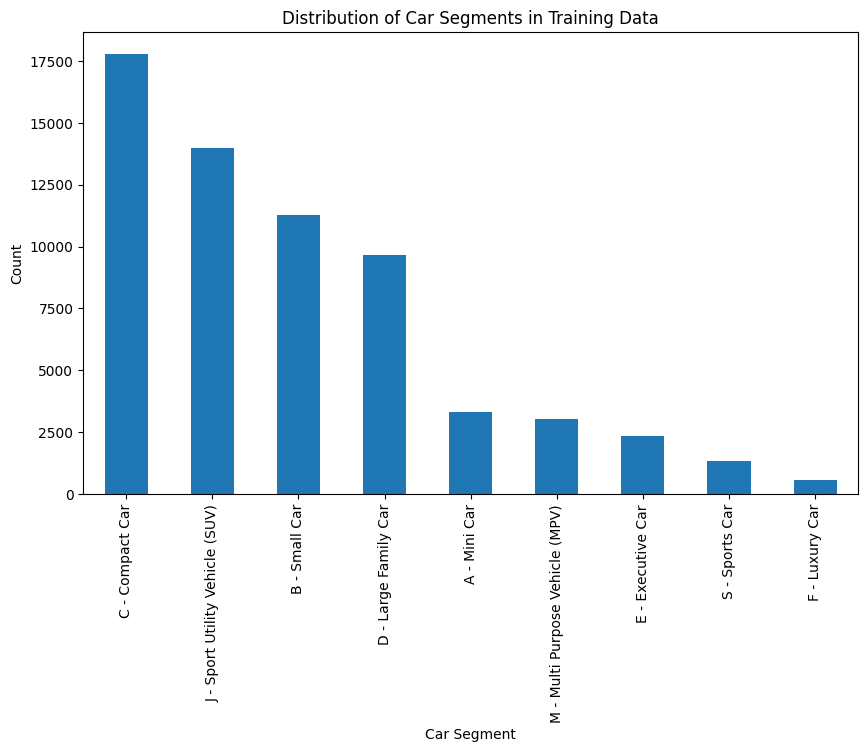

In [35]:
# Plot the distribution of car_segment in the training data
car_segment_counts = X_train['car_segment'].value_counts()
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
car_segment_counts.plot(kind='bar')
plt.title('Distribution of Car Segments in Training Data')
plt.xlabel('Car Segment')
plt.ylabel('Count')
plt.show()

Target count per segment: 17775
After oversampling:
X_train shape: (159975, 36)
y_train shape: (159975,)
After oversampling:
X_train shape: (159975, 36)
y_train shape: (159975,)


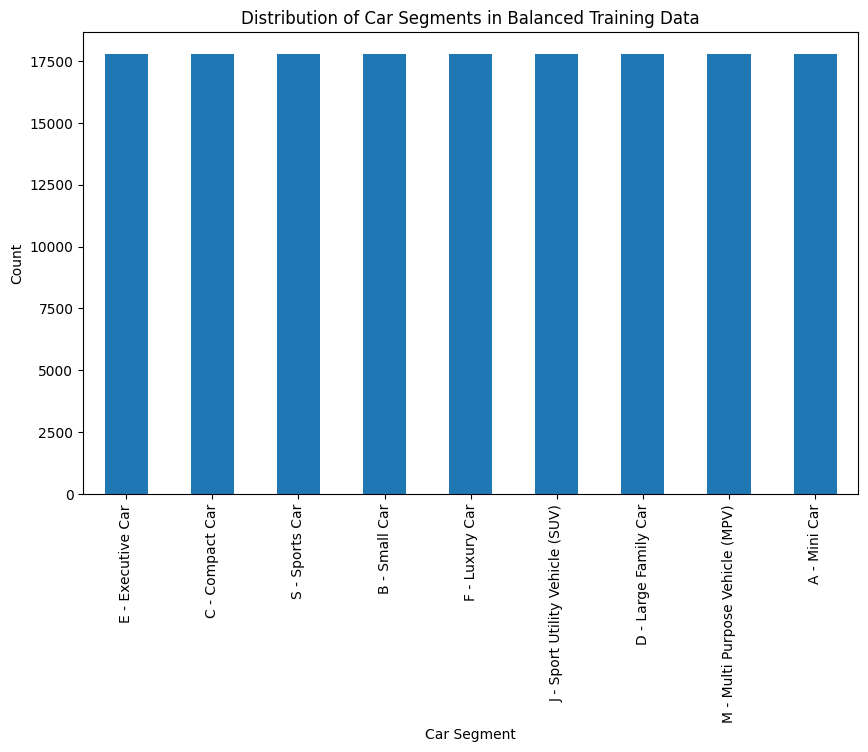

In [36]:
# Oversampling car_segment to balance the dataset
from sklearn.utils import resample

# Combine X_train and y_train for resampling
train_data = X_train.copy()
train_data['price'] = y_train

# Reset index so carID becomes a column and is preserved during resampling
# We check if the index has a name, if so we preserve it.
if train_data.index.name == 'carID':
    train_data = train_data.reset_index()

# Calculate the target count (count of the majority class)
max_count = train_data['car_segment'].value_counts().max()
print(f"Target count per segment: {max_count}")

balanced_dfs = []

# Loop through each unique car_segment and resample to max_count
for segment in train_data['car_segment'].unique():
    df_segment = train_data[train_data['car_segment'] == segment]
    
    # Resample to match max_count
    df_resampled = resample(
        df_segment,
        replace=True,     # Sample with replacement
        n_samples=max_count, # Match majority class size
        random_state=RANDOM_STATE
    )
    balanced_dfs.append(df_resampled)

# Combine all balanced dataframes
train_data_balanced = pd.concat(balanced_dfs, ignore_index=True)

# Shuffle the balanced dataset
train_data_balanced = train_data_balanced.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

# Set carID back as index if it exists
if 'carID' in train_data_balanced.columns:
    train_data_balanced = train_data_balanced.set_index('carID')

# Separate back into X_train and y_train
X_train = train_data_balanced.drop(columns=['price'])
y_train = train_data_balanced['price']

print("After oversampling:")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

# Plot the new distribution of car_segment in the balanced training data
car_segment_counts_balanced = X_train['car_segment'].value_counts()
plt.figure(figsize=(10,6))
car_segment_counts_balanced.plot(kind='bar')
plt.title('Distribution of Car Segments in Balanced Training Data')
plt.xlabel('Car Segment')
plt.ylabel('Count')
plt.show()

In [37]:
# Check the head of X_train after balancing
print("Final X_train preview:")
display(X_train.head())

Final X_train preview:


,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,previousOwners,hasDamage,mpg_diff_transmission,car_age,efficiency_ratio,mileage_per_year,first_owner_flag,many_owners_flag,engine_tax_ratio,age_per_10k_miles,high_mileage_flag,very_high_mileage_flag,liter_per_mpg,engine_per_age,mpg_per_age,tax_per_age,mpg_x_engine,tax_x_engine,mpg_x_tax,engine_x_age,mpg_x_age,tax_x_age,year_centered,tax_per_liter,tax_per_mpg,brand_segment,car_segment
carID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
11822,BMW,5 Series,2017.0,Automatic,39728.00000,Diesel,125.0,60.1,2.0,3.0,0.0,6.8,3.0,28.619048,12815.483871,0,1,0.015987,0.603282,1,0,0.033223,0.645161,19.387097,40.322581,120.20,250.0,7512.5,6.0,180.3,375.0,0.0,59.523810,2.076412,Premium,E - Executive Car
20287,Ford,Focus,2017.0,Manual,82584.13442,Diesel,20.0,74.3,1.5,4.0,0.0,16.6,3.0,46.437500,26640.043361,0,1,0.074627,0.324030,1,1,0.020161,0.483871,23.967742,6.451613,111.45,30.0,1486.0,4.5,222.9,60.0,0.0,12.500000,0.268817,Medium,C - Compact Car
8385,BMW,4 Series,2017.0,Automatic,30145.00000,Diesel,145.0,58.9,2.0,4.0,0.0,5.6,3.0,28.047619,9724.193548,0,1,0.013784,0.747291,0,0,0.033898,0.645161,19.000000,46.774194,117.80,290.0,8540.5,6.0,176.7,435.0,0.0,69.047619,2.457627,Premium,S - Sports Car
60466,Opel,Corsa,2020.0,Manual,398.00000,Petrol,150.0,52.3,1.2,3.0,0.0,-5.4,0.0,40.230769,3980.000000,0,1,0.007995,0.000000,0,0,0.022901,12.000000,523.000000,1500.000000,62.76,180.0,7845.0,0.0,0.0,0.0,3.0,115.384615,2.862595,Low,B - Small Car
43056,Mercedes-Benz,CL-Class,2019.0,Semi-Auto,5498.00000,Petrol,150.0,40.9,2.0,2.0,0.0,-10.5,1.0,19.476190,4998.181818,0,0,0.013324,0.645245,0,0,0.048780,1.818182,37.181818,136.363636,81.80,300.0,6135.0,2.0,40.9,150.0,2.0,71.428571,3.658537,Premium,F - Luxury Car


In [38]:
# Check if every row has a carID
if X_train.index.name == 'carID':
    print("All rows in X_train have a carID index.")
if X_val.index.name == 'carID':
    print("All rows in X_val have a carID index.")

All rows in X_train have a carID index.
All rows in X_val have a carID index.


# 7. Encoding

We encode categorical features into numerical values using OneHotEncoder.
We use `ColumnTransformer` to apply encoding to specific columns while keeping others intact.


In [39]:
# Define columns for encoding
# OneHot Encoding for nominal variables
# Ensure column names match the DataFrame exactly
onehot_cols = ['Brand', 'fuelType', 'transmission', 'model', 'brand_segment', 'car_segment']

# Initialize encoders
# handle_unknown='ignore' is crucial to avoid errors if new categories appear in test data
onehot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Create ColumnTransformer for encoding
# We use 'passthrough' for the rest of the columns (numerical ones) so they are not lost
encoding_transformer = ColumnTransformer(
    transformers=[
        ('onehot', onehot_encoder, onehot_cols)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False 
)

# Fit on TRAIN data only
print("Fitting encoder on X_train...")
encoding_transformer.fit(X_train)

# Transform all datasets
print("Transforming X_train...")
X_train_encoded_array = encoding_transformer.transform(X_train)
print("Transforming X_val...")
X_val_encoded_array = encoding_transformer.transform(X_val)
print("Transforming X_test...")
X_test_encoded_array = encoding_transformer.transform(X_test)

# Get feature names
# For OneHotEncoder, we can get feature names. For passthrough, we need the original names of the rest.
# In recent sklearn, get_feature_names_out() handles this automatically.
feature_names = encoding_transformer.get_feature_names_out()

# Convert back to DataFrames
X_train = pd.DataFrame(X_train_encoded_array, columns=feature_names, index=X_train.index)
X_val = pd.DataFrame(X_val_encoded_array, columns=feature_names, index=X_val.index)
X_test = pd.DataFrame(X_test_encoded_array, columns=feature_names, index=X_test.index)

print(f"Shape after encoding: {X_train.shape}")
display(X_train.head())

Fitting encoder on X_train...
Transforming X_train...
Transforming X_val...
Transforming X_test...
Transforming X_train...
Transforming X_val...
Transforming X_test...
Shape after encoding: (159975, 240)
Shape after encoding: (159975, 240)


,Brand_Audi,Brand_BMW,Brand_Ford,Brand_Hyundai,Brand_Mercedes-Benz,Brand_Opel,Brand_Toyota,Brand_Volkswagen,Brand_Škoda,fuelType_Diesel,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,transmission_Automatic,transmission_Manual,transmission_Other,transmission_Semi-Auto,model_1 Series,model_2 Series,model_3 Series,model_4 Series,model_5 Series,model_6 Series,model_7 Series,model_8 Series,model_A-Class,model_A1,model_A2,model_A3,model_A4,model_A5,model_A6,model_A7,model_A8,model_Adam,model_Agila,model_Amarok,model_Ampera,model_Antara,model_Arteon,model_Astra,model_Auris,model_Avensis,model_Aygo,model_B-Class,model_B-MAX,model_Beetle,model_C-Class,model_C-HR,model_C-MAX,model_CC,model_CH-R,model_CL-Class,model_CLA-Class,model_CLC-Class,model_CLK-Class,model_CLS-Class,model_Caddy,model_Caddy Life,model_Caddy Maxi,model_Caddy Maxi Life,model_California,model_Camry,model_Caravelle,model_Citigo,model_Combo Life,model_Corolla,model_Corsa,model_Crossland X,model_E-Class,model_EcoSport,model_Edge,model_Eos,model_Fabia,model_Fiesta,model_Focus,model_Fusion,model_G-Class,model_GL-Class,model_GLA-Class,model_GLB-Class,model_GLC-Class,model_GLE-Class,model_GLS-Class,model_GT86,model_GTC,model_Galaxy,model_Getz,model_Golf,model_Golf SV,model_Grand C-MAX,model_Grand Tourneo Connect,model_Grandland X,model_Hilux,model_Insignia,model_Ioniq,model_Jetta,model_Ka,model_Ka+,...,model_S5,model_S8,model_SL-Class,model_SLK-Class,model_SQ5,model_SQ7,model_Santa Fe,model_Scala,model_Scirocco,model_Sharan,model_Shuttle,model_StreetKa,model_Superb,model_Supra,model_T-Cross,model_T-Roc,model_TT,model_Terracan,model_Tiguan,model_Tiguan Allspace,model_Touareg,model_Touran,model_Tourneo Connect,model_Tourneo Custom,model_Tucson,model_Up,model_Urban Cruiser,model_V-Class,model_Vectra,model_Verso,model_Verso-S,model_Viva,model_Vivaro,model_X-Class,model_X1,model_X2,model_X3,model_X4,model_X5,model_X6,model_X7,model_Yaris,model_Yeti,model_Yeti Outdoor,model_Z3,model_Z4,model_Zafira,model_Zafira Tourer,model_i10,model_i20,model_i3,model_i30,model_i40,model_i8,model_i800,model_iQ,model_ix20,model_ix35,brand_segment_Low,brand_segment_Medium,brand_segment_Premium,car_segment_A - Mini Car,car_segment_B - Small Car,car_segment_C - Compact Car,car_segment_D - Large Family Car,car_segment_E - Executive Car,car_segment_F - Luxury Car,car_segment_J - Sport Utility Vehicle (SUV),car_segment_M - Multi Purpose Vehicle (MPV),car_segment_S - Sports Car,year,mileage,tax,mpg,engineSize,previousOwners,hasDamage,mpg_diff_transmission,car_age,efficiency_ratio,mileage_per_year,first_owner_flag,many_owners_flag,engine_tax_ratio,age_per_10k_miles,high_mileage_flag,very_high_mileage_flag,liter_per_mpg,engine_per_age,mpg_per_age,tax_per_age,mpg_x_engine,tax_x_engine,mpg_x_tax,engine_x_age,mpg_x_age,tax_x_age,year_centered,tax_per_liter,tax_per_mpg
carID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
11822,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2017.0,39728.00000,125.0,60.1,2.0,3.0,0.0,6.8,3.0,28.619048,12815.483871,0.0,1.0,0.015987,0.603282,1.0,0.0,0.033223,0.645161,19.387097,40.322581,120.20,250.0,7512.5,6.0,180.3,375.0,0.0,59.523810,2.076412
20287,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.

# 8. Scaling

We scale numerical features using RobustScaler to handle outliers effectively.
We fit the scaler on the training data and transform all datasets.

In [40]:
# Safety check to remove any leaked interval columns (like 'mpg_bin' or 'mileage_bin')
# This can happen if the Imputer classes weren't re-executed after the fix.
def drop_interval_cols(df):
    # Identify columns with Interval data type
    interval_cols = df.select_dtypes(include=['interval']).columns.tolist()
    # Also check for specific names just in case
    bin_cols = [c for c in df.columns if c.endswith('_bin')]
    cols_to_drop = list(set(interval_cols + bin_cols))
    
    if cols_to_drop:
        print(f"Dropping leaked columns: {cols_to_drop}")
        return df.drop(columns=cols_to_drop)
    return df

X_train = drop_interval_cols(X_train)
X_val = drop_interval_cols(X_val)
X_test = drop_interval_cols(X_test)

# Double check dtypes
print("Data types after cleanup:")
print(X_train.dtypes.value_counts())

Data types after cleanup:
float64    240
Name: count, dtype: int64


In [13]:
# Initialize Scaler
# RobustScaler is good for handling outliers
scaler = RobustScaler()

# Fit on TRAIN data only
print("Fitting scaler on X_train...")
scaler.fit(X_train)

# Transform all datasets
print("Transforming X_train...")
X_train_scaled = scaler.transform(X_train)
print("Transforming X_val...")
X_val_scaled = scaler.transform(X_val)
print("Transforming X_test...")
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrames (scaler returns numpy array)
X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_val = pd.DataFrame(X_val_scaled, columns=X_val.columns, index=X_val.index)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Scaling complete.")
display(X_train.describe())

Fitting scaler on X_train...
Transforming X_train...
Transforming X_train...
Transforming X_val...
Transforming X_val...
Transforming X_test...
Scaling complete.
Transforming X_test...
Scaling complete.


,Brand_Audi,Brand_BMW,Brand_Ford,Brand_Hyundai,Brand_Mercedes-Benz,Brand_Opel,Brand_Toyota,Brand_Volkswagen,Brand_Škoda,fuelType_Diesel,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,transmission_Automatic,transmission_Manual,transmission_Other,transmission_Semi-Auto,model_1 Series,model_2 Series,model_3 Series,model_4 Series,model_5 Series,model_6 Series,model_7 Series,model_8 Series,model_A-Class,model_A1,model_A2,model_A3,model_A4,model_A5,model_A6,model_A7,model_A8,model_Adam,model_Agila,model_Amarok,model_Ampera,model_Antara,model_Arteon,model_Astra,model_Auris,model_Avensis,model_Aygo,model_B-Class,model_B-MAX,model_Beetle,model_C-Class,model_C-HR,model_C-MAX,model_CC,model_CH-R,model_CL-Class,model_CLA-Class,model_CLC-Class,model_CLK-Class,model_CLS-Class,model_Caddy,model_Caddy Life,model_Caddy Maxi,model_Caddy Maxi Life,model_California,model_Camry,model_Caravelle,model_Cascada,model_Citigo,model_Combo Life,model_Corolla,model_Corsa,model_Crossland X,model_E-Class,model_EcoSport,model_Edge,model_Eos,model_Fabia,model_Fiesta,model_Focus,model_Fusion,model_G-Class,model_GL-Class,model_GLA-Class,model_GLB-Class,model_GLC-Class,model_GLE-Class,model_GLS-Class,model_GT86,model_GTC,model_Galaxy,model_Getz,model_Golf,model_Golf SV,model_Grand C-MAX,model_Grand Tourneo Connect,model_Grandland X,model_Hilux,model_Insignia,model_Ioniq,model_Jetta,model_Ka,...,model_SL-Class,model_SLK-Class,model_SQ5,model_SQ7,model_Santa Fe,model_Scala,model_Scirocco,model_Sharan,model_Shuttle,model_StreetKa,model_Superb,model_Supra,model_T-Cross,model_T-Roc,model_TT,model_Terracan,model_Tigra,model_Tiguan,model_Tiguan Allspace,model_Touareg,model_Touran,model_Tourneo Connect,model_Tourneo Custom,model_Tucson,model_Up,model_Urban Cruiser,model_V-Class,model_Vectra,model_Veloster,model_Verso,model_Verso-S,model_Viva,model_Vivaro,model_X-Class,model_X1,model_X2,model_X3,model_X4,model_X5,model_X6,model_X7,model_Yaris,model_Yeti,model_Yeti Outdoor,model_Z3,model_Z4,model_Zafira,model_Zafira Tourer,model_i10,model_i20,model_i3,model_i30,model_i40,model_i8,model_i800,model_iQ,model_ix20,model_ix35,brand_segment_Low,brand_segment_Medium,brand_segment_Premium,car_segment_A - Mini Car,car_segment_B - Small Car,car_segment_C - Compact Car,car_segment_D - Large Family Car,car_segment_E - Executive Car,car_segment_F - Luxury Car,car_segment_J - Sport Utility Vehicle (SUV),car_segment_M - Multi Purpose Vehicle (MPV),car_segment_S - Sports Car,year,mileage,tax,mpg,engineSize,previousOwners,hasDamage,mpg_diff_transmission,car_age,efficiency_ratio,mileage_per_year,first_owner_flag,many_owners_flag,engine_tax_ratio,age_per_10k_miles,high_mileage_flag,very_high_mileage_flag,liter_per_mpg,engine_per_age,mpg_per_age,tax_per_age,mpg_x_engine,tax_x_engine,mpg_x_tax,engine_x_age,mpg_x_age,tax_x_age,year_centered,tax_per_liter,tax_per_mpg
count,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.00000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000000,63296.000

In [41]:
# Check for NaN values in each dataset
def check_nan(df, name):
    nan_cols = df.columns[df.isna().any()].tolist()
    if nan_cols:
        print(f"{name} has NaN values in columns: {nan_cols}")
    else:
        print(f"{name} has no NaN values.")

# Use the correct variable names (X_train, X_val, X_test)
check_nan(X_train, "X_train")
check_nan(y_train.to_frame(), "y_train")
check_nan(X_val, "X_val")
check_nan(y_val.to_frame(), "y_val")
check_nan(X_test, "X_test")

X_train has no NaN values.
y_train has no NaN values.
X_val has no NaN values.
y_val has no NaN values.
X_test has no NaN values.


In [48]:
# Check if every row has a carID
if y_train.index.name == 'carID':
    print("All rows in y_train have a carID index.")
if y_val.index.name == 'carID':
    print("All rows in y_val have a carID index.")

All rows in y_train have a carID index.
All rows in y_val have a carID index.


# 9. Save Processed Data

We save the processed datasets to CSV files for use in the modeling phase.
We save both the standard encoded version and the version without OneHotEncoding for Brand (if needed).

In [49]:
# Get current date string
date_str = datetime.now().strftime("%Y%m%d_%H%M")

# Define output directory
output_dir = os.path.join(data_dir, f'encoded_data/{date_str}')
os.makedirs(output_dir, exist_ok=True)

# Save the processed datasets
print(f"Saving processed data to {output_dir}...")

# Save with index=True to keep carID
X_train.to_csv(os.path.join(output_dir, '12_X_train.csv'), index=True)
y_train.to_csv(os.path.join(output_dir, '12_y_train.csv'), index=True)

X_val.to_csv(os.path.join(output_dir, '12_X_val.csv'), index=True)
y_val.to_csv(os.path.join(output_dir, '12_y_val.csv'), index=True)

X_test.to_csv(os.path.join(output_dir, '12_X_test.csv'), index=True)

print("Data saving complete.")
print(f"Train shape: {X_train.shape}")
print(f"Val shape: {X_val.shape}")
print(f"Test shape: {X_test.shape}")

Saving processed data to ../data/encoded_data/20251210_1713...
Data saving complete.
Train shape: (159975, 240)
Val shape: (11171, 240)
Test shape: (32567, 240)
Data saving complete.
Train shape: (159975, 240)
Val shape: (11171, 240)
Test shape: (32567, 240)
